In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from torch.utils.data import TensorDataset, DataLoader

Check whether google colab kernel is used

In [2]:
import sys 

IN_COLAB = 'google.colab' in sys.modules
IN_COLAB

False

#### Download Data

In [5]:
if IN_COLAB:
    import urllib.request

    base_url = "https://raw.githubusercontent.com/atleer/forecast-electricity-markets/main/data/processed/opsd-time_series-2020-10-06"
    splits = ['train', 'validation', 'test']
    filename = 'time_series_60min_singleindex.parquet'

    for split in splits:
        dir_path = f"data/processed/opsd-time_series-2020-10-06/{split}"
        os.makedirs(dir_path, exist_ok=True)
        url = f"{base_url}/{split}/{filename}"
        dest = f"{dir_path}/{filename}"
        urllib.request.urlretrieve(url, dest)
        print(f"Downloaded {split}")

    root_dir = Path('.')

    

In [14]:
if IN_COLAB:
    root_dir = Path('.')
else:
    notebook_path = %pwd
    root_dir = Path(notebook_path).parent.parent.parent

Set seed and turn of non-deterministic behavior for reproducibility

In [16]:
SEED = 2026

def set_seed(seed: int = 2026) -> None:
    """Set seed and disable non-deterministic behavior for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

Set device

In [17]:
def set_device(device: str = 'cpu') -> str:
    """Set device to CUDA if available. Set to cpu if not."""
    if torch.cuda.is_available():
        device = 'cuda'
    else:
        device = 'cpu'
    return device

device = set_device()

Load Processed Data

In [18]:
processed_data_dir = root_dir / 'data/processed/opsd-time_series-2020-10-06'
filepaths = list(processed_data_dir.glob('**/*60*.parquet'))

for filepath in filepaths:
    if 'train' in filepath.parts:
        df_train = pd.read_parquet(filepath)
    elif 'validation' in filepath.parts:
        df_val = pd.read_parquet(filepath)
    elif 'test' in filepath.parts:
        df_test = pd.read_parquet(filepath)

Choose columns to use in data

In [19]:
features_column_names = ['DE_wind_generation', 'DE_price_ahead']
targets_column_names = ['DE_price_ahead']

Scale data

Open question: Should I use different scaling than standardization with mean?

In [20]:
features_mean = df_train[features_column_names].mean(axis=0).values
targets_mean = df_train[targets_column_names].mean(axis=0).values

features_std = df_train[features_column_names].std(axis=0).values
targets_std = df_train[targets_column_names].std(axis=0).values


In [21]:
features_train = ((df_train[features_column_names].values - features_mean)/features_std)
features_val = ((df_val[features_column_names].values - features_mean)/features_std)
features_test = ((df_test[features_column_names].values - features_mean)/features_std)

targets_train = ((df_train[targets_column_names].values - targets_mean)/targets_std)
targets_val = ((df_val[targets_column_names].values - targets_mean)/targets_std)
targets_test = ((df_test[targets_column_names].values - targets_mean)/targets_std)

## Forecast price ahead using both historical price data and wind generation

Create sequences

In [22]:
def create_sequences(features, targets, input_len: int = 48, horizon: int = 24):
    """Create sequences for seq2seq forecasting
    
    Args:
        features: data to use in forecast
        targets: data to forecast
        input_len: past timesteps to use in forecast (encoder window length)
        horizon: future timesteps to forecast (decoder window length)

    Returns:
        X: (n_samples, input_len, n_features) inputs to encoder
        y: (n_samples, horizon, n_targets) targets (labels) for decoder
    """

    n_samples = len(features)

    X = np.empty((n_samples - input_len - horizon, input_len, features.shape[-1]))
    y = np.empty((n_samples - input_len - horizon, horizon, targets.shape[-1]))

    for i_sample in range(n_samples - input_len - horizon):
        for i_feature in range(features.shape[-1]):
            X[i_sample,:,i_feature] = features[i_sample:(i_sample + input_len), i_feature]

        for i_feature in range(targets.shape[-1]):
            y[i_sample,:,i_feature] = targets[(i_sample + input_len):(i_sample + input_len + horizon), i_feature]

    return np.array(X), np.array(y)

In [23]:
input_len = 48
horizon = 24

In [24]:
if targets_train.ndim == 1:
    targets_train = np.expand_dims(targets_train, axis=-1)
    targets_val = np.expand_dims(targets_val, axis=-1)
    targets_test = np.expand_dims(targets_test, axis=-1)

X_train, y_train = create_sequences(features_train, targets_train, input_len, horizon)
X_val, y_val = create_sequences(features_val, targets_val, input_len, horizon)
X_test, y_test = create_sequences(features_test, targets_test, input_len, horizon)

Create Seq2Seq Model

In [25]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, enc_input_size: int = 2, dec_input_size: int = 1, hidden_size: int = 64, num_layers: int = 1,):
        super().__init__()
        self.encoder = nn.GRU(input_size=enc_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.decoder = nn.GRU(input_size=dec_input_size, hidden_size=hidden_size, batch_first=True, device=device)
        self.fc = nn.Linear(hidden_size, dec_input_size, device=device)

    def forward(self, X: torch.Tensor, horizon: int, y_teacher: torch.Tensor | None = None, teacher_threshold: float = 0.5):

        # encode input
        enc_output, hidden = self.encoder(X)
        #print(f'enc_output.shape: {enc_output.shape}')

        #print(f'encoder hidden.shape: {hidden.shape}')

        # seed for decoder: the last observed price
        # TODO: Can't this be y? Check
        dec_input = X[:, -1:, 1:2] # dims: (batch, 1, 1)

        #print(f'X.shape: {X.shape}, dec_input.shape: {dec_input.shape}')

        predictions = []
        for time_step in range(horizon):
            # decode
            dec_output, hidden = self.decoder(dec_input, hidden)
            #print(f'dec_output: {dec_output.shape}, decoder hidden.shape: {hidden.shape}')

            # make prediction from output of decoder
            prediction = self.fc(dec_output)
            #print(f'prediction.shape: {prediction.shape}')
            predictions.append(prediction)

            apply_teacher_forcing = (y_teacher is not None 
                                     and torch.rand(1).item() < teacher_threshold)

            if apply_teacher_forcing:
                dec_input = y_teacher[:, time_step:time_step+1].unsqueeze(1)
            else:
                dec_input = prediction


        # concatinate over dim 1 so that horizon is on second dimension and batches on first
        return torch.cat(predictions, dim=1)

Create DataLoader

In [26]:
X_train = torch.tensor(X_train, dtype = torch.float32, device=device)
y_train = torch.tensor(y_train, dtype = torch.float32, device=device)

train_dataset = TensorDataset(X_train, y_train)

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Train

In [27]:
def train(model: nn.Module, dataloader: DataLoader, horizon: int, optimizer: torch.optim.Optimizer, criterion = nn.MSELoss(), nepochs: int = 50):
    """Train a neural network model

    Args:
        model: Model to train.
        dataloader: dataloader containing features and targets
        horizon: number of time steps into the future to forecast
        optimizer: optimization algorithm
        criterion: loss function
        nepochs: Number of training epochs

    Returns:
        A tuple of (losses, accuracies). Each is a list of values recorded
        at each epoch during training.
    """


    losses = []
    for epoch in tqdm(range(nepochs)):
        for batch_idx, (X_batch, y_batch) in enumerate(dataloader):
            optimizer.zero_grad()

            predictions = model(X_batch, horizon=horizon)

            loss = criterion(predictions, y_batch)

            loss.backward()

            optimizer.step()

            losses.append(loss.item())

        if (epoch % 10) == 0:
            print(f'epoch: {epoch}, loss: {loss.item():.3f}')

In [28]:
model = Seq2SeqGRU(enc_input_size=2, dec_input_size = 1)

In [ ]:
learning_rate = 0.001
nepochs = 50

optimizer = torch.optim.Adam(lr = learning_rate, params=model.parameters())

criterion = nn.MSELoss()

model.train()
train(model, train_dataloader, horizon = 24, optimizer = optimizer, nepochs=nepochs)

SyntaxError: invalid syntax (2450206338.py, line 10)

Plot forecast on training data

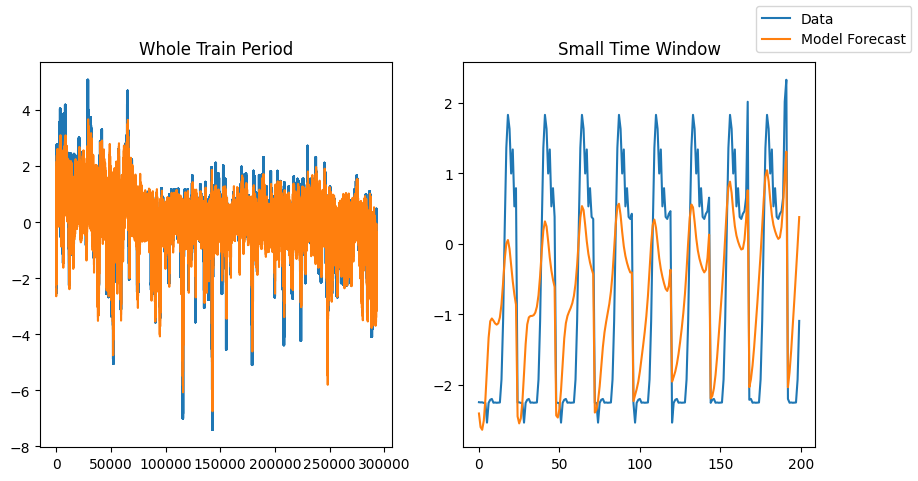

In [32]:
y_pred_train = model(X_train, horizon = horizon)

fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))

axes[0].set_title('Whole Train Period')
axes[0].plot(y_train.cpu().numpy().flatten(), label = 'Data')
with torch.no_grad():
    axes[0].plot(y_pred_train.cpu().numpy().flatten(), label = 'Model Forecast')

window_start = 0
window_end = window_start + 200
axes[1].set_title('Small Time Window')
axes[1].plot(y_train.cpu().numpy().flatten()[window_start:window_end])
with torch.no_grad():
    axes[1].plot(y_pred_train.cpu().numpy().flatten()[window_start:window_end])

fig.legend();

Test

In [43]:
X_test = torch.tensor(X_test, dtype = torch.float32, device=device)
y_test = torch.tensor(y_test, dtype = torch.float32, device=device)

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test, horizon = 24)


/tmp/ipykernel_1161/2762229588.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype = torch.float32, device=device)
/tmp/ipykernel_1161/2762229588.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype = torch.float32, device=device)


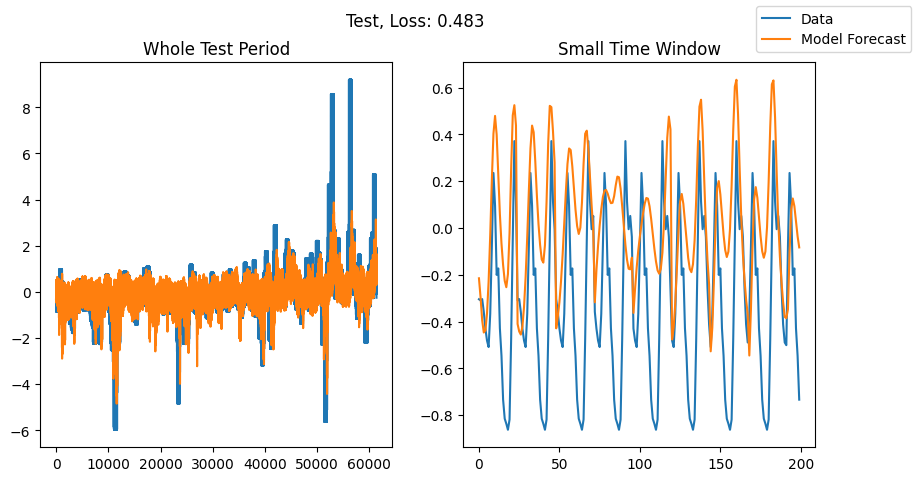

In [44]:
fig, axes = plt.subplots(ncols = 2, figsize = (10, 5))

axes[0].set_title('Whole Test Period')
axes[0].plot(y_test.cpu().numpy().flatten(), label = 'Data')
axes[0].plot(y_pred_test.cpu().numpy().flatten(), label = 'Model Forecast')

test_loss = torch.mean((y_test - y_pred_test)**2).item()
fig.suptitle(f'Test, Loss: {test_loss:.3f}')

axes[1].set_title('Small Time Window')
window_start = 0
window_end = window_start + 200
axes[1].plot(y_test.cpu().numpy().flatten()[window_start:window_end])
axes[1].plot(y_pred_test.cpu().numpy().flatten()[window_start:window_end])

fig.legend();

In [25]:
X_train.shape

torch.Size([12206, 48, 2])